In [1]:
import sys
from datetime import date, timedelta
from pathlib import Path


def _find_project_src(start: Path) -> Path:

    for base in [start, *start.parents]:
        candidate = base / "src" / "data_ingestion"
        if candidate.exists():
            return base / "src"

    two_up = start.parent.parent
    candidate = two_up / "src" / "data_ingestion"
    if candidate.exists():
        return two_up / "src"

    raise RuntimeError("Could not locate project src/data_ingestion from notebook cwd")


SRC_PATH = _find_project_src(Path.cwd().resolve())
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib.pyplot as plt
import pandas as pd

from data_ingestion.pipeline import run_to_jsonl

plt.style.use("seaborn-v0_8")

In [2]:
end_date = date.today()
start_date = end_date - timedelta(days=7)

output_path = Path("data/regular_processed_records.jsonl")
output_path.parent.mkdir(parents=True, exist_ok=True)

fetcher_specs = [
    {
        "source": "openalex",
        "config": {
            "query": "data engineering",
            "max_pages": 1,
            "per_page": 50,
        },
    },
    {
        "source": "crossref",
        "config": {
            "query": "data engineering",
            "max_pages": 1,
            "rows": 50,
        },
    },
]

transform_spec = {
    "transforms": [
        {"op": "require_fields", "fields": ["title", "url"]},
        {
            "op": "include_terms",
            "terms": ["data", "engineering", "pipeline", "etl"],
            "fields": ["title", "abstract", "topic"],
        },
        {"op": "dedupe", "keys": ["source", "external_id", "url"]},
    ]
}

summary = run_to_jsonl(
    fetcher_specs=fetcher_specs,
    output_file=str(output_path),
    append=False,
    fail_fast=False,
    transform_spec=transform_spec,
    start_date=start_date.isoformat(),
    end_date=end_date.isoformat(),
)
summary

2026-03-15 18:07:58,299 | INFO     | data_ingestion.pipeline | run_to_jsonl called output=data/regular_processed_records.jsonl specs=2 append=False fail_fast=False
2026-03-15 18:07:58,300 | INFO     | data_ingestion.pipeline | Applying date overrides start_date=2026-03-08 end_date=2026-03-15 specs=2
2026-03-15 18:07:58,301 | INFO     | data_ingestion.factories | Built fetcher source=openalex class=OpenAlexFetcher
2026-03-15 18:07:58,301 | INFO     | data_ingestion.factories | Built fetcher source=crossref class=CrossRefFetcher
2026-03-15 18:07:58,302 | INFO     | data_ingestion.factories | Built 2 fetcher(s)
2026-03-15 18:07:58,303 | INFO     | data_ingestion.pipeline | Pipeline initialized fail_fast=False enrich_full_text=False sink_write_batch_size=500 transforms_enabled=True resume=False checkpoint=None
2026-03-15 18:07:58,303 | INFO     | data_ingestion.pipeline | Pipeline run started
2026-03-15 18:07:58,304 | INFO     | data_ingestion.pipeline | Starting source=openalex
2026-03-15

PipelineSummary(total_records=100, by_source={'openalex': 50, 'crossref': 50}, failed_sources={}, by_source_stats={'openalex': SourceRunStats(seen=50, kept=50, dropped_by_topic=0, dropped_by_transform=0, checkpoint_skipped=0), 'crossref': SourceRunStats(seen=50, kept=50, dropped_by_topic=0, dropped_by_transform=0, checkpoint_skipped=0)}, output_target='data/regular_processed_records.jsonl', resumed_from_checkpoint=False, checkpoint_path=None, checkpoint_entries=0)

In [3]:
df = pd.read_json(output_path, lines=True)
df.head()

,source,external_id,title,authors,published_date,url,abstract,full_text,full_text_url,topic,record_type,fetched_at
0,openalex,https://openalex.org/W4200065432,International Journal of Multimedia Data Engin...,"[Chengcui Zhang, Shu-Ching Chen]",2026-03-11,https://doi.org/10.4018/ijmdem,None,NaN,https://doi.org/10.4018/ijmdem,Image Retrieval and Classification Techniques,article,2026-03-15 22:07:58.734451+00:00
1,openalex,https://openalex.org/W4235929402,Applied Mechanics and Materials,"[Ullah, Hanif, Marí Soucase, Bernabé, Cui, Hai...",2026-03-14,http://hdl.handle.net/10251/39227,"""Applied Mechanics and Materials"" is a peer-re...",NaN,http://hdl.handle.net/10251/39227,Material Properties and Applications,article,2026-03-15 22:07:58.734637+00:00
2,openalex,https://openalex.org/W76711023,Materials Science Forum,"[D. Dompoint, Irina G. Galben-Sandulache, Alex...",2026-03-12,https://hal.archives-ouvertes.fr/hal-00781895,Materials Science Forum (MSF) is a peer-review...,NaN,https://hal.science/hal-02193762/document,Silicon Carbide Semiconductor Technologies,article,2026-03-15 22:07:58.734731+00:00
3,openalex,https://openalex.org/W2460119131,Defect and Diffusion Forum,[],2026-03-14,https://doi.org/10.4028/www.scientific.net/ddf,Defect and Diffusion Forum (DDF) (formerly Par...,NaN,https://doi.org/10.4028/www.scientific.net/ddf,Advancements in Photolithography Techniques,article,2026-03-15 22:07:58.734821+00:00
4,openalex,https://openalex.org/W4232384861,Solid State Phenomena,[],2026-03-11,https://doi.org/10.4028/www.scientific.net/ssp,Solid State Phenomena (formerly Part B of “Dif...,NaN,https://doi.org/10.4028/www.scientific.net/ssp,Materials science,article,2026-03-15 22:07:58.734925+00:00


In [4]:
print(f"Total rows: {len(df)}")
display(df[["source", "record_type", "topic"]].head(10))

Total rows: 100


,source,record_type,topic
0,openalex,article,Image Retrieval and Classification Techniques
1,openalex,article,Material Properties and Applications
2,openalex,article,Silicon Carbide Semiconductor Technologies
3,openalex,article,Advancements in Photolithography Techniques
4,openalex,article,Materials science
5,openalex,article,Big Data and Business Intelligence
6,openalex,article,Big Data and Business Intelligence
7,openalex,article,Modulation (music)
8,openalex,article,Modulation (music)
9,openalex,article,Customer churn and segmentation


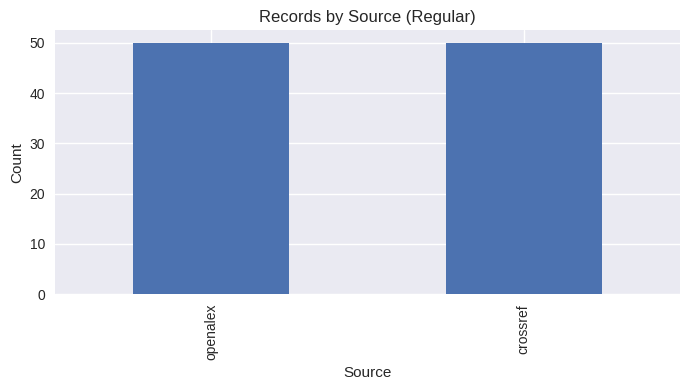

In [5]:
ax = (
    df["source"]
    .value_counts()
    .plot(kind="bar", figsize=(7, 4), title="Records by Source (Regular)")
)
ax.set_xlabel("Source")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

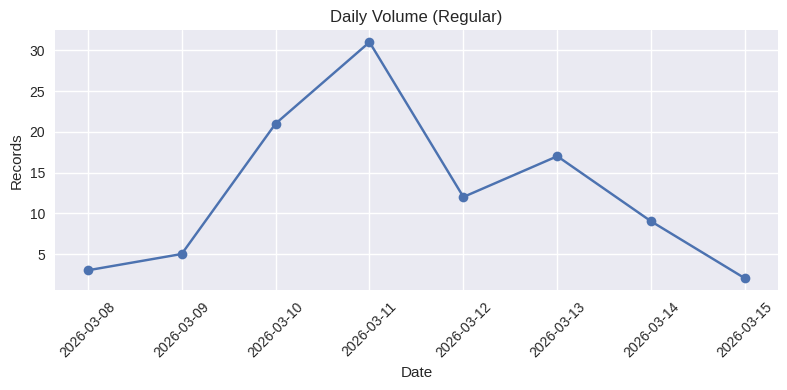

In [6]:
timeline = df.copy()
timeline["published_date"] = pd.to_datetime(timeline["published_date"], errors="coerce")
daily = (
    timeline.dropna(subset=["published_date"])
    .groupby(timeline["published_date"].dt.date)
    .size()
)
ax = daily.plot(kind="line", marker="o", figsize=(8, 4), title="Daily Volume (Regular)")
ax.set_xlabel("Date")
ax.set_ylabel("Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

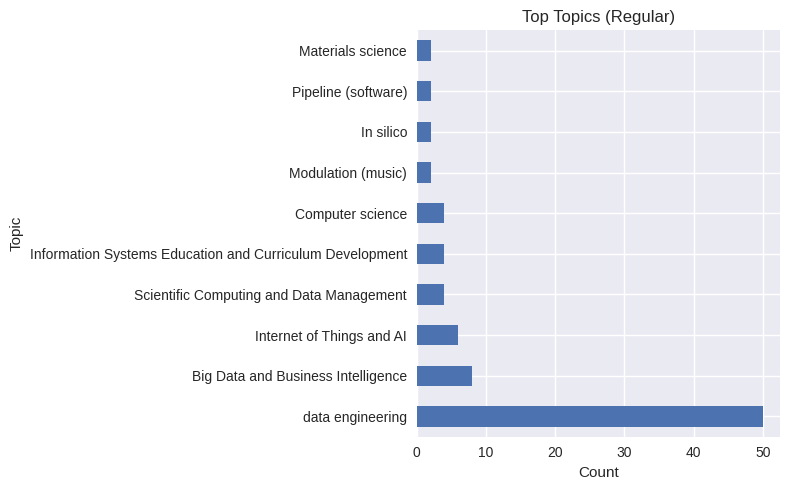

In [7]:
top_topics = df["topic"].fillna("unknown").value_counts().head(10)
ax = top_topics.plot(kind="barh", figsize=(8, 5), title="Top Topics (Regular)")
ax.set_xlabel("Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()

In [8]:
stats_rows = []
if hasattr(summary, "by_source_stats") and summary.by_source_stats:
    for source, stats in summary.by_source_stats.items():
        stats_rows.append(
            {
                "source": source,
                "seen": stats.seen,
                "kept": stats.kept,
                "dropped_by_topic": stats.dropped_by_topic,
                "dropped_by_transform": stats.dropped_by_transform,
                "checkpoint_skipped": stats.checkpoint_skipped,
            }
        )
else:
    for source, count in summary.by_source.items():
        stats_rows.append(
            {
                "source": source,
                "seen": count,
                "kept": count,
                "dropped_by_topic": 0,
                "dropped_by_transform": 0,
                "checkpoint_skipped": 0,
            }
        )

stats_df = pd.DataFrame(stats_rows).sort_values("kept", ascending=False)
stats_df

,source,seen,kept,dropped_by_topic,dropped_by_transform,checkpoint_skipped
0,openalex,50,50,0,0,0
1,crossref,50,50,0,0,0


In [9]:
analysis_df = df.copy()
analysis_df["published_date"] = pd.to_datetime(
    analysis_df["published_date"], errors="coerce"
)

duplicates_by_external_id = (
    analysis_df[analysis_df["external_id"].notna()]
    .duplicated(subset=["source", "external_id"])
    .sum()
)
duplicates_by_url = (
    analysis_df[analysis_df["url"].notna()].duplicated(subset=["source", "url"]).sum()
)

quality = pd.DataFrame(
    {
        "rows": [len(analysis_df)],
        "unique_sources": [analysis_df["source"].nunique(dropna=True)],
        "missing_topic_pct": [analysis_df["topic"].isna().mean() * 100],
        "missing_abstract_pct": [analysis_df["abstract"].isna().mean() * 100],
        "duplicates_by_external_id": [int(duplicates_by_external_id)],
        "duplicates_by_url": [int(duplicates_by_url)],
    }
)
quality

,rows,unique_sources,missing_topic_pct,missing_abstract_pct,duplicates_by_external_id,duplicates_by_url
0,100,2,0.0,32.0,0,0


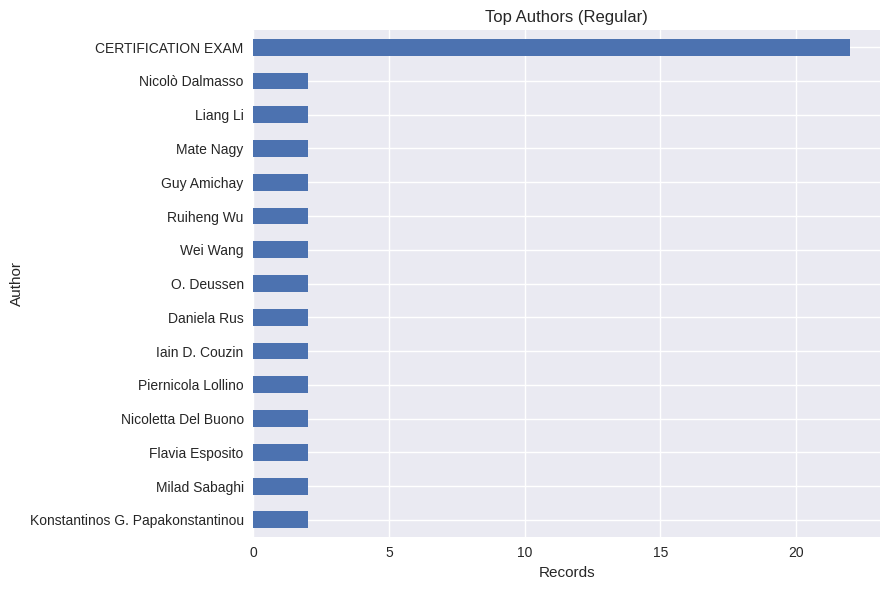

In [10]:
def _coerce_authors(value):
    if isinstance(value, list):
        return [item for item in value if isinstance(item, str) and item.strip()]
    return []


author_df = analysis_df.copy()
author_df["authors"] = author_df["authors"].apply(_coerce_authors)
author_counts = (
    author_df.explode("authors")
    .dropna(subset=["authors"])["authors"]
    .value_counts()
    .head(15)
)

if author_counts.empty:
    print("No author data available for author-frequency analysis.")
else:
    ax = author_counts.sort_values().plot(
        kind="barh",
        figsize=(9, 6),
        title="Top Authors (Regular)",
    )
    ax.set_xlabel("Records")
    ax.set_ylabel("Author")
    plt.tight_layout()
    plt.show()

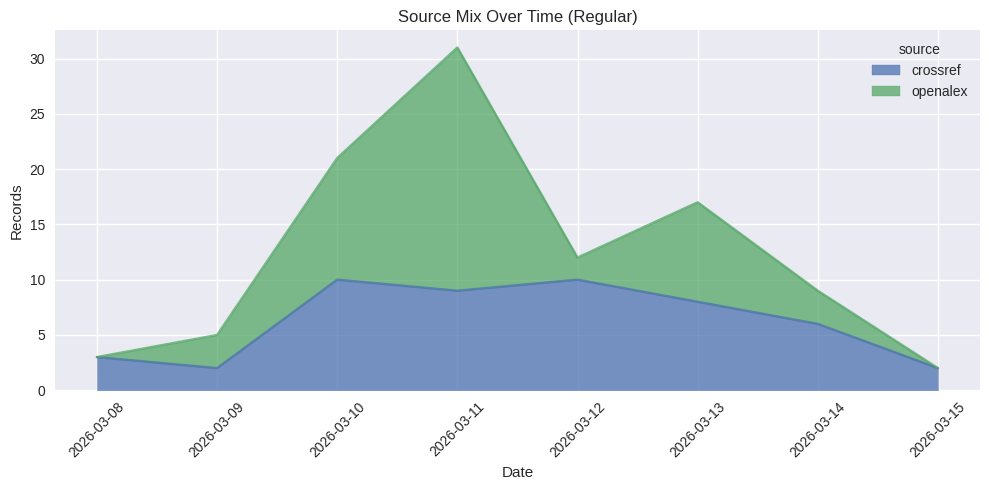

In [11]:
daily_source = (
    analysis_df.dropna(subset=["published_date"])
    .groupby([analysis_df["published_date"].dt.date, "source"])
    .size()
    .unstack(fill_value=0)
)

if daily_source.empty:
    print("No dated records available for source-mix trend analysis.")
else:
    ax = daily_source.plot(
        kind="area",
        stacked=True,
        figsize=(10, 5),
        title="Source Mix Over Time (Regular)",
        alpha=0.75,
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Records")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

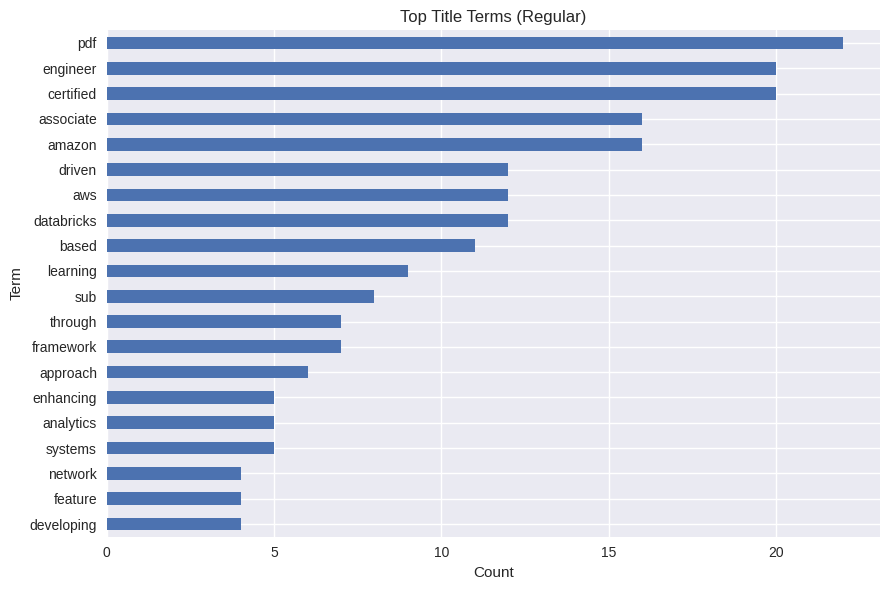

In [12]:
stop_words = {
    "the",
    "and",
    "for",
    "with",
    "from",
    "into",
    "data",
    "engineering",
    "using",
    "study",
    "system",
    "analysis",
    "model",
    "models",
}
tokens = analysis_df["title"].fillna("").str.lower().str.findall(r"[a-z]{3,}").explode()
tokens = tokens[tokens.notna() & ~tokens.isin(stop_words)]
top_terms = tokens.value_counts().head(20)

if top_terms.empty:
    print("No title token data available for keyword analysis.")
else:
    ax = top_terms.sort_values().plot(
        kind="barh",
        figsize=(9, 6),
        title="Top Title Terms (Regular)",
    )
    ax.set_xlabel("Count")
    ax.set_ylabel("Term")
    plt.tight_layout()
    plt.show()